In [22]:
# ===== ЯЧЕЙКА 1 — Импорты =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay,
                             PrecisionRecallDisplay, average_precision_score)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
print("Библиотеки загружены")

Библиотеки загружены


In [23]:
# ===== ЯЧЕЙКА 2 — Загрузка чистых данных =====
df = pd.read_csv(r'/Single-Bidder Prediction in Public Procurement/data/tenders_clean.csv')
print("Размер:", df.shape)
print("Колонки:", df.columns.tolist())
print("\nПервые строки:")
df.head(3)

Размер: (150000, 9)
Колонки: ['Type', 'Contract_Type', 'Procedure_Type', 'Contracting_Authority', 'Contracting_Authority_Activity_Type', 'Award_Criteria_Type', 'Currency', 'CPV_Code', 'single_bidder']

Первые строки:


,Type,Contract_Type,Procedure_Type,Contracting_Authority,Contracting_Authority_Activity_Type,Award_Criteria_Type,Currency,CPV_Code,single_bidder
0,Anunt de atribuire la anunt de participare,Lucrari,Negociere,E-ON DISTRIBUTIE ROMANIA S.A.,"Producere, transport si distributie de gaz si ...",Pretul cel mai scazut,RON,45231113-0,0
1,Anunt de atribuire la cerere de oferta,Furnizare,Invitatie de participare,Institutul National de Medicina Legala Mina Mi...,Sanatate,Pretul cel mai scazut,RON,33141000-0,0
2,Anunt de atribuire la cerere de oferta,Furnizare,Invitatie de participare,"SPITALUL DE PSIHIATRIE ""DR. GH. PREDA"" SIBIU",NaN,Pretul cel mai scazut,RON,33661500-6,0


In [24]:
# ===== ЯЧЕЙКА 3 — Кодирование признаков =====

df_enc = df.copy()

# --- Frequency encoding ---
for col in ['Contracting_Authority', 'CPV_Code']:
    freq = df_enc[col].value_counts(normalize=True)
    df_enc[col + '_freq'] = df_enc[col].map(freq)
    df_enc.drop(columns=[col], inplace=True)

# --- Label encoding для остальных категориальных ---
cat_cols = ['Type', 'Contract_Type', 'Procedure_Type',
            'Contracting_Authority_Activity_Type',
            'Award_Criteria_Type', 'Currency']

for col in cat_cols:
    df_enc[col] = df_enc[col].astype('category').cat.codes

print("Готово! Итоговые колонки:")
print(df_enc.dtypes)
print("\nПропуски:")
print(df_enc.isnull().sum())

Готово! Итоговые колонки:
Type                                      int8
Contract_Type                             int8
Procedure_Type                            int8
Contracting_Authority_Activity_Type       int8
Award_Criteria_Type                       int8
Currency                                  int8
single_bidder                            int64
Contracting_Authority_freq             float64
CPV_Code_freq                          float64
dtype: object

Пропуски:
Type                                   0
Contract_Type                          0
Procedure_Type                         0
Contracting_Authority_Activity_Type    0
Award_Criteria_Type                    0
Currency                               0
single_bidder                          0
Contracting_Authority_freq             0
CPV_Code_freq                          0
dtype: int64


In [25]:
# ===== ЯЧЕЙКА 4 — Заполнение пропусков =====
# Если остались пропуски (NaN) — заполняем медианой для чисел
df_enc.fillna(df_enc.median(numeric_only=True), inplace=True)
print("Пропусков после заполнения:", df_enc.isnull().sum().sum())


Пропусков после заполнения: 0


In [26]:
# ===== ЯЧЕЙКА 5 — Разбивка на train / test =====
X = df_enc.drop(columns=['single_bidder'])
y = df_enc['single_bidder']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Test:  {X_test.shape[0]} строк")
print(f"\nДоля single-bidder в train: {y_train.mean():.1%}")
print(f"Доля single-bidder в test:  {y_test.mean():.1%}")


Train: 120000 строк
Test:  30000 строк

Доля single-bidder в train: 19.9%
Доля single-bidder в test:  19.9%


In [27]:
# ===== ЯЧЕЙКА 6 — Бейзлайн: Логистическая регрессия =====
# Логистическая регрессия — простейшая модель классификации.
# class_weight='balanced' автоматически учитывает дисбаланс классов.
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("=== Логистическая регрессия ===")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Конкурентный', 'Single-bidder']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba_lr):.4f}")

=== Логистическая регрессия ===
               precision    recall  f1-score   support

 Конкурентный       0.88      0.80      0.83     24044
Single-bidder       0.40      0.56      0.47      5956

     accuracy                           0.75     30000
    macro avg       0.64      0.68      0.65     30000
 weighted avg       0.78      0.75      0.76     30000

ROC-AUC:  0.7474
PR-AUC:   0.4995


In [28]:
# ===== ЯЧЕЙКА 7 — Основная модель: XGBoost =====
# XGBoost — мощная модель на основе деревьев решений.
# scale_pos_weight учитывает дисбаланс: (кол-во 0) / (кол-во 1)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 2)
print(f"scale_pos_weight = {spw}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Конкурентный', 'Single-bidder']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba_xgb):.4f}")


scale_pos_weight = 4.04

=== XGBoost ===
               precision    recall  f1-score   support

 Конкурентный       0.93      0.76      0.83     24044
Single-bidder       0.44      0.77      0.56      5956

     accuracy                           0.76     30000
    macro avg       0.68      0.76      0.69     30000
 weighted avg       0.83      0.76      0.78     30000

ROC-AUC:  0.8495
PR-AUC:   0.6380


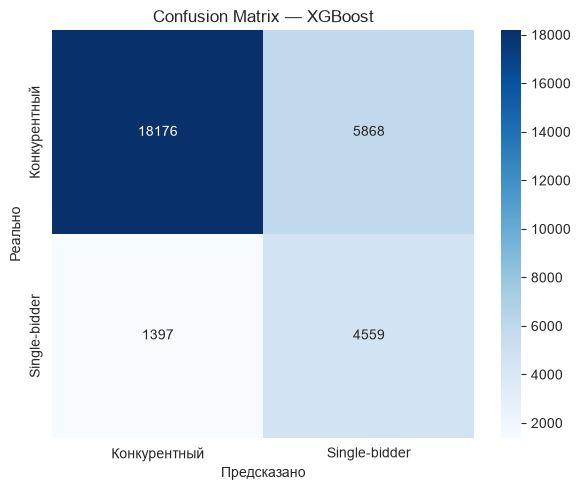

In [29]:
# ===== ЯЧЕЙКА 8 — Confusion Matrix (XGBoost) =====
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Конкурентный', 'Single-bidder'],
            yticklabels=['Конкурентный', 'Single-bidder'])
plt.title('Confusion Matrix — XGBoost')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.tight_layout()
plt.savefig('/Single-Bidder Prediction in Public Procurement/figures/confusion_matrix.png', dpi=120)
plt.show()


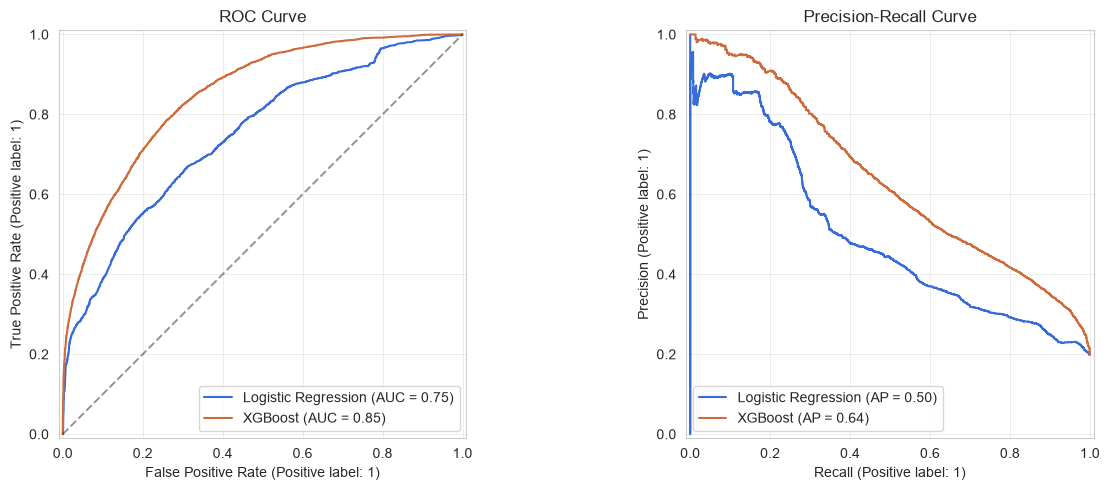

In [30]:
# ===== ЯЧЕЙКА 9 — ROC-AUC кривые обеих моделей =====
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr, name='Logistic Regression', ax=axes[0])
RocCurveDisplay.from_predictions(
    y_test, y_proba_xgb, name='XGBoost', ax=axes[0])
axes[0].set_title('ROC Curve')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)

PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_lr, name='Logistic Regression', ax=axes[1])
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_xgb, name='XGBoost', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('/Single-Bidder Prediction in Public Procurement/figures/roc_pr_curves.png', dpi=120)
plt.show()

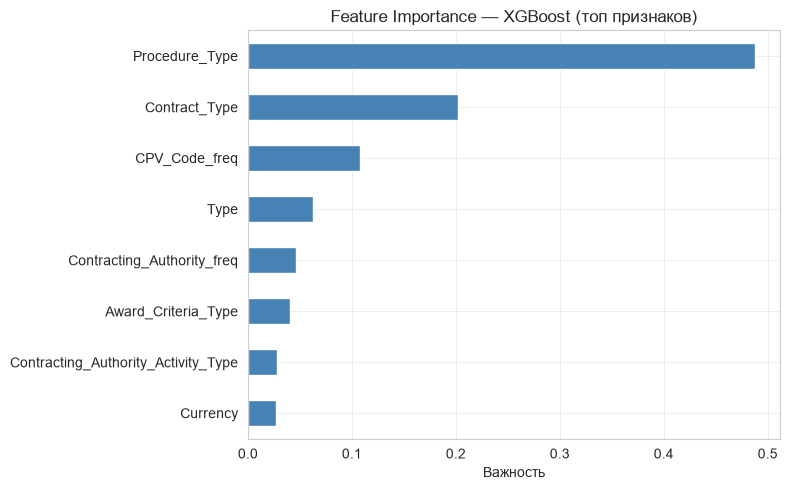


Топ-5 важных признаков:
Procedure_Type                0.487446
Contract_Type                 0.202381
CPV_Code_freq                 0.107410
Type                          0.062105
Contracting_Authority_freq    0.045839
dtype: float32


In [31]:
# ===== ЯЧЕЙКА 10 — Feature Importance (XGBoost) =====
importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — XGBoost (топ признаков)')
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig('/Single-Bidder Prediction in Public Procurement/figures/feature_importance.png', dpi=120)
plt.show()

print("\nТоп-5 важных признаков:")
print(importances.sort_values(ascending=False).head(5))


In [32]:
# ===== ЯЧЕЙКА 11 — Итоговое сравнение моделей =====
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_proba_lr), 4),
        round(roc_auc_score(y_test, y_proba_xgb), 4)
    ],
    'PR-AUC': [
        round(average_precision_score(y_test, y_proba_lr), 4),
        round(average_precision_score(y_test, y_proba_xgb), 4)
    ],
    'F1 (single-bidder)': [
        round(pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True))
              .loc['f1-score', '1'], 4),
        round(pd.DataFrame(classification_report(y_test, y_pred_xgb, output_dict=True))
              .loc['f1-score', '1'], 4)
    ]
})

print("\n=== Итоговое сравнение ===")
print(results.to_string(index=False))


=== Итоговое сравнение ===
              Model  ROC-AUC  PR-AUC  F1 (single-bidder)
Logistic Regression   0.7474  0.4995              0.4673
            XGBoost   0.8495  0.6380              0.5566
